# Independent component analysis

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Be able to use ICA;
- Understand the difference between PCA and ICA;
- Understand the properties ICA;
- Understand the limitations ICA;
- Understand how ICA can be used for cleaning of data (e.g., from artefacts).

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.decomposition import FastICA

## (Optional) Exercise 1: applications of ICA
1. Find an interesting application of ICA and post a link to it (e.g., the blog post, article, podcast, video, etc.) on the Brightspace assignment forum of Week 04. Describe the application in several sentences. As the subject of your post, use a sensible title that explains the body: i.e., use a title like `group $<$number$>$: $<$your application$>$', where you fill in your group and the application you found.
1. Try to dig deep into your application. Please answer questions that come up on the forum. We might also ask you to answer questions that come up during the flipped-classroom session.
1. Interact with other groups by commenting on their posts. Elaborate on why you think their application is an interesting one (or not); would you want to know more about it (what and why)? Are there any parts that are unclear to you? Do you have any suggestions (e.g., other related sources of information)? Etc.

## Exercise 2: the difference between _uncorrelated_ and _statistical independence_
The goal of this exercise is to understand the difference between _uncorrelated_ and _statistical independent_ data sets.

In the previous assignment, you have seen that principal component analysis (PCA) finds a set of __orthogonal (uncorrelated)__ basis vectors pointing in the directions of maximal variance of the data set. Formally, two random variables $\mathbf X$ and $\mathbf Y$ are defined to be uncorrelated $:\Longleftrightarrow$ their covariance $\bf \operatorname{cov}(X,Y) = E(XY) − E(X)E(Y)$ is zero. Now, remember the Pearson's correlation coefficient:

$\begin{equation} \bf \rho_{X,Y}= \frac{\operatorname{cov}(X,Y)}{\sigma_X \sigma_Y} \end{equation}$

If you compare the definition of uncorrelated and the definition of the correlation coefficient, you can easily see that two random variables with non-zero variance are uncorrelated $\Longleftrightarrow$ their correlation coefficient is zero. 

Independent component analysis (ICA) on the other hand is trying to find a set of basis vectors which are __statistically independent__. On an intuitive level, statistical independence between $\mathbf X$ and $\mathbf Y$ means that information about the outcome of $\mathbf X$ does not change the probability of the outcome of the other variable $\mathbf Y$. More rigorously, two random variables $\mathbf X$ and $\mathbf Y$ with cumulative distribution functions $F_X(x)$ and $F_Y(y)$, and probability density function $f_X(x)$ and $f_Y(y)$, are independent $\Longleftrightarrow$ the combined random variable $(\mathbf X, \mathbf Y)$ has a joint cumulative distribution function $F_{X,Y}(x,y)$ satisfying:

$\begin{equation} F_{X,Y}(x,y) = F_X(x) F_Y(y) \end{equation}$

1. Which of the data sets in (x,y) are uncorrelated? Which are statistically independent? Which of the two properties is stronger? **Hint:** The correlation coefficient is zero (and thus X, Y are uncorrelated) if the slope of a linear fit is zero.

![title](data/Independence.png)

Answer here

## Exercise 3: basics about ICA
Next, we want to cover the basics of ICA. ICA is a computational method for separating a multivariate signal (e.g. sounds) into (independent) additive subcomponents (e.g. speakers or singers). The standard model for ICA for the same number of sources and signals is:

\begin{equation} 
\mathbf x = \mathbf {A s}
\end{equation}

where $\mathbf x=(x_i,...x_D)$ is a column vector with the observations (e.g. in time) $\mathbf x_i \in \mathbb R^T$, $\mathbf s=(s_1,...s_D)$ is the source vector containing the original components $\mathbf s_i \in \mathbb R^T$ and $\mathbf A \in \mathbb R^{D \times D}$ is a linear transformation that defines the linear mixing of the constituent signals. Typically, $\mathbf A$ and $\mathbf s$ are unknown.

1. What are the central assumptions for the ICA to work? 

Answer here

## Exercise 4: ambiguities in ICA
In comparison to PCA, ICA has two major ambiguities:
1. We cannot determine the variances (energies) of the independent components;
2. We cannot determine the order of the independent components.

Answer the following:
1. Why do these ambiguities occur? **Hint:** Answer this question by looking at the standard forward model $\mathbf x = \mathbf {As}$.

Answer:  
Both ambiguities arise from the fact that in the equation $\mathbf x = \mathbf {As}$ we have two unknown quantities ($A$ and $s$), and we are trying to reconstruct them with only the $\mathbf{x}$ data in hand.

<b>Variances (energies) of the independent components</b>:   
if you multiply the component $s_i$ by a number $c$, and divide the corresponding column of the matrix  $A$ by $c$, the observed mixture $\mathbf{x}$ will not change. Therefore, the exact variances of the components cannot be determined.  

Example:  
* The source of $s_i$ has some meaning.
* If we multiply it by a number, for example $2$, then it becomes twice as large.
* But at the same time, we can divide the corresponding column of the matrix $A$ by $2$.
    * It was: $\mathbf{x} = \mathbf{A}\mathbf{s} = \mathbf{a}_1 s_1 + \mathbf{a}_2 s_2 + \ldots + \mathbf{a}_D s_D$ (where $\mathbf{a}_i$  is the $i$ column of the matrix $A$)
    * It became: $\mathbf{x} = (\mathbf{a}_1 / \alpha) \cdot (\alpha s_1) + \mathbf{a}_2 s_2 + \ldots + \mathbf{a}_D s_D$
    * Nothing has changed in the observed $\mathbf{x}$ signals, it is the same mix. For ICA, solutions $(\mathbf{A}, \mathbf{s})$  and $(\mathbf{A}', \mathbf{s}')$ (где $\mathbf{a}'_1 = \mathbf{a}_1 / \alpha$, а $s'_1 = \alpha s_1$) are impossible to distinguish based on data $\mathbf{x}$ alone.

As a result, their product $\mathbf{A}\mathbf{s}$ (and hence the observations $\mathbf{x}$) will not change.    
That is, we will never know whether the source was "loud" or "quiet" in fact this can always be compensated in $A$ (e.g., it is impossible to distinguish a loud source, poorly represented in the mixture, from a quiet source, strongly represented in the mixture.)


<b>Order of the independent components</b>:   
rearranging the columns in $A$ and the corresponding components in $s$ also does not change $\mathbf{x}$. Therefore, the order of the independent components is indeterminate.

Example:   
If we take the matrix $A$ and simply swap its two columns, and swap the corresponding components in the vector $s$, then the product $\mathbf{A}\mathbf{s}$ will still remain the same.
* It was: $\mathbf{x} = \mathbf{A}\mathbf{s} = \mathbf{a}_1 s_1 + \mathbf{a}_2 s_2 + \ldots + \mathbf{a}_D s_D$ (where $\mathbf{a}_i$  is the $i$ column of the matrix $A$)
* It became: $\mathbf{x} = \mathbf{a}_2 s_2 + \mathbf{a}_1 s_1 + \mathbf{a}_3 s_3 + \ldots + \mathbf{a}_D s_D$.

As a result, it is impossible to determine which reconstructed signal is the first original source and which is the second.

## (Optional) Exercise 5:  FastICA and negentropy
Here, you will use an implementation of ICA which is called FastICA. It is an iterative fixed-point scheme which is minimizing the entropy (or equivalently maximizing the negative entropy (negentropy)) in order to find the independent components. 

The entropy of a random variable can be interpreted as the degree of information that the observation of the variable gives. The more “random”, i.e.  unpredictable and unstructured the variable is, the larger its entropy. 

1. Find out which special property the normal distribution has with respect to entropy for a fixed variance. How can this property be used for finding the independent components?

A more rigurous derivation can be found here: [Paper about ICA](https://www.cs.helsinki.fi/u/ahyvarin/papers/NN00new.pdf) in Chapter 4.

Answer here

## Exercise 6: preprocessing before ICA
Before applying ICA, most algorithms expect you to preprocess your data. Commonly, two preprocessing steps are applied before performing an ICA: __Centering__ and __Whitening__.

__Centering__ is done by simply subtracting the sample mean, i.e. $\bf x_c = x - \bar x$. This is equivalent to a translation of the data such that they are positioned around the origin.

__Whitening__ is a transformation that converts the data such that it has an identity covariance matrix. Let $\hat \Sigma$ be the estimated covariance matrix. Then $\bf x_w = \hat \Sigma^{-\frac{1}{2}} x_c$ would be the new whitened vector with zero mean and identity covariance matrix. 

One popular method for whitening is to use the eigenvalue decomposition (EVD) of the covariance matrix: $\bf \hat \Sigma = EDE^T$ where ${\bf E}$ is the orthogonal matrix of eigenvectors of $\hat \Sigma$ and ${\bf D}$ is the diagonal matrix of its eigenvalues, ${\bf D}= \text{diag}(d_1,...,d_D)$. Whitening can now be done by computing

$\begin{equation} {\bf x_w}={\bf E}{\bf D}^{-1/2}{\bf E}^T {\bf x_c} \end{equation}$

where the matrix ${\bf D}^{-1/2}$ is computed by a simple component-wise operation as ${\bf D}^{-1/2}=\text{diag}(d_1^{-1/2},...,d_D^{-1/2})$.

Below you see an implementation and the effect of centering and whitening.
1. Why is it useful to whiten the data?

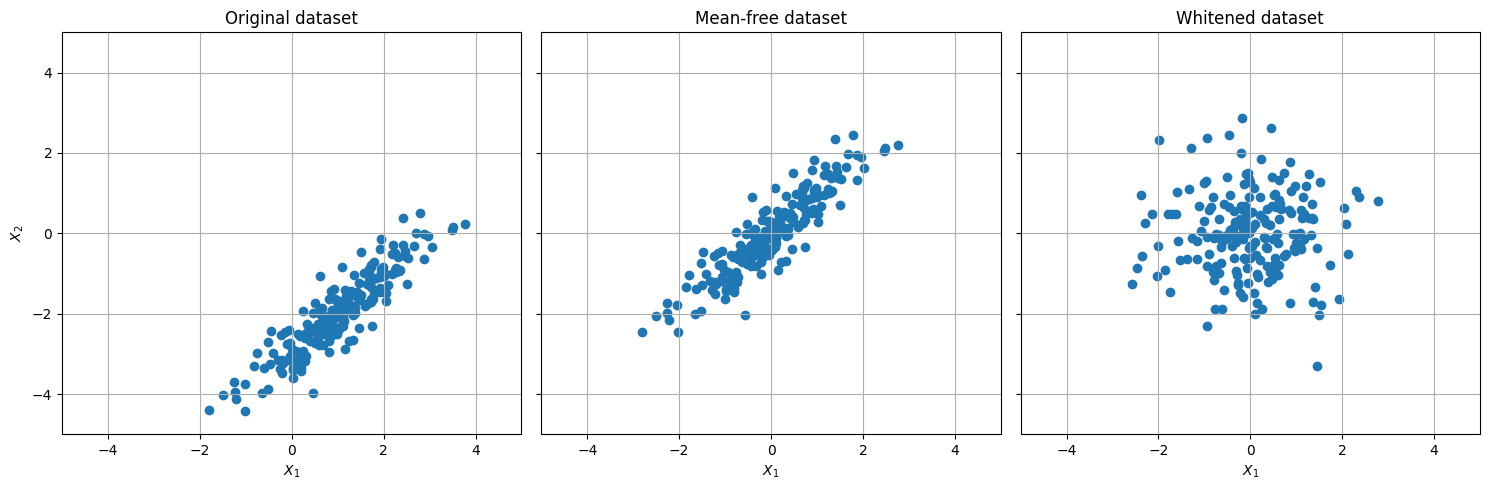

In [3]:
# Create normally distributed dataset
N_samples = 200;
X = np.random.multivariate_normal([1, -2], [[1, 0.9], [0.9, 1]], N_samples) #средн знач:X₁≈1,X₂≈-2 ков матр: дисперс=1, ков = 0.9 (сильная корреляция)

# Centering
mean = np.mean(X, axis=0) # Вычисляем среднее значение по каждому измерению (столбцу).
X_meanfree = X - mean  # Центрирование: вычитаем среднее, чтобы данные имели нулевое мат. ожидание.

# Whitening
cov = np.cov(X.T)
[D, E] = np.linalg.eig(cov) # Spectral decomposition: ковматрицу на:  D-eigvals(дисперсии вдоль глав направлий)   E-eigvecs (главн направлия)
D = np.diag(1 / np.sqrt(D))  # Нормируем: превращаем дисперсии в единичные (1/√D).
X_white = np.dot(np.dot(np.dot(E, D), E.T), X_meanfree.T).T   # X_white = E × D⁻¹/² × Eᵀ × X_meanfree
# E.T -поворот в пространство глав компонент        E - обратный поворот
#D - масштаб-ние до единичной дисперсии       .T в конце - транспонирование обратно к исходной ориентации
#print(np.cov(X_white.T)) # Should be identity      #ков матрица отбеленных данных должна быть единичной

# Draw the figure
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)    
for k in range(3):
    if k==0:
        X_temp = X
        ax[k].set_title('Original dataset') #Поочередно подготавливаем данные для каждого графика.
    elif k == 1:
        X_temp = X_meanfree
        ax[k].set_title('Mean-free dataset')
    elif k == 2:
        X_temp = X_white 
        ax[k].set_title('Whitened dataset')           
    
    ax[k].scatter(X_temp[:, 0], X_temp[:, 1])  #Рисуем scatter plot для X₁ vs X₂.
    ax[k].set_xlim([-5, 5])
    ax[k].set_ylim([-5, 5])
    ax[k].grid()
    ax[k].set_xlabel('$X_1$') #Настраиваем оси, сетку и подписи.
ax[0].set_ylabel('$X_2$')
fig.tight_layout()


Answer here

## Exercise 7: blind source separation using FastICA
Imagine the following situation: there are three singers in a sound studio. Each of the singers ("sound source") generates a sound wave $s_{i}(t)$ over time $t$. The singers are surrounded by three microphones while each of those are recording the arriving sound $x_{j}(t)$. Given the observations of the three microphones $x_{j}(t), j=\{1,2,3\}$, we now want to compute a reconstruction of the contribution of each singer $s_{i,rec}(t)$ using an ICA model.

**Note:** In the following code, the true sources $S_{true}$ as well as the mixing matrix $A$ are given to generate the observations $X$. In a real world scenario, this would of course not be the case. Instead, you want to reconstruct the independent sources $S_{rec}$ and the estimated mixing matrix $\hat A$. This means we **ONLY** have access to our observations $X$.

1. Inspect the given generative model for constructing a data set of the above described scenario;
1. Train a FastICA model in order to reconstruct $s_{i,rec}(t)$ of each singer. You can use the FastICA implementation of the scikit-learn toolbox;
1. Visualize the observations $x_{j}(t)$ of every microphone, the reconstructed source signals $s_{i,rec}(t)$ and the true sources for all three components $s_{i,true}(t)$. Use the function `visualize_data()` as you need to do such kind of plots a few times within this exercise;
1. Compare the time series of the reconstructed sources with the true sources in terms of their order and sign. What do you observe?
1. Plot histograms of the estimated sources;
1. Verify the distribution of the estimated independent components. Which types of distributions do you expect the ICA to return?

In [4]:
def visualize_data(models, names):
    '''plot figure with subplot for each specified model, 
    in each subplot all three components are shown
    Input: list 'models', 'names' 
    Usage: visualize_data(models = [X, S_true], names = ['observations X', 'true sources'])'''
    colors = ['red', 'skyblue', 'orange']
    plt.figure(figsize=(12, 8))
    for i, (model, name) in enumerate(zip(models, names), 1):
        plt.subplot(len(names), 1, i)
        plt.title(name, fontsize=15)
        for sig, color in zip(model.T, colors):
            plt.plot(sig + i * 2 * max(sig), color=color)
    plt.subplots_adjust(0.09, 0.04, 0.94, 0.94, 0.26, 0.46)
    
# Generate sample data
np.random.seed(35)
N_samples = 2000
time = np.linspace(0, 8, N_samples) # Создаем 2000 временных точек от 0 до 8 секунд.

# Singer 1: sinusoidal signal
s1 = np.sin(3 * time)  
# Singer 2: square signal
s2 = np.sign(np.sin(4 * time))
# Singer 3: saw tooth пилообразную signal           постепенно нарастает и резко падает
s3 = signal.sawtooth(2 * np.pi * time)  

# Concatenate the true single sources and add noise 
S_true = np.c_[s1, s2, s3]    #Объединяем три голоса в одну матрицу 2000×3.
S_true += 0.5 * np.random.normal(size=S_true.shape)    #Добавляем небольшой шум к голосам (как реальные помехи). 

# Standardize the data
S_true /= S_true.std(axis=0)    #Нормируем данные - делаем стандартное отклонение = 1 для каждого голоса.

# Mix data
A = np.array([[1, 1, 1], [0.3, 2, 1.2], [1.5, 1.2, 2.4]])  # Mixing matrix    [1, 1, 1] - Микрофон1 слышит всех певцов одинаково громко
X = np.dot(S_true, A.T)  # чистые голоса Умножаем на матрицу смешивания=X - 3 записи, где каждый микрофон содержит смесь всех трех голосов!

Answer 4:
Первое, на что следует обратить внимание, это то, что цвета не совпадают. 
Это имеет смысл, поскольку ICA не знает порядок расположения истинных источников, поэтому они каждый раз выбираются случайным образом.
В то время как некоторые реконструированные линии очень хорошо совпадают с истинными, другие реконструированные линии, похоже, перевернуты по знаку.
Кроме того, масштаб восстановленных линий не совсем соответствует действительности. 
Например, самый низкий из истинных источников находится в диапазоне от 10 до 15 по оси y, в то время как восстановленный источник не обязательно соответствует этому значению.
Это различие по оси y также приводит к тому, что расстояние между отдельными сигналами отличается от расстояния между истинными источниками.
Таким образом, порядок следования сигналов не обязательно совпадает, особенно по цвету.
Знак и масштабирование сигналов также могут отличаться от оригинальных источников.
Это разумно, поскольку ICA не знает истинного масштаба или 

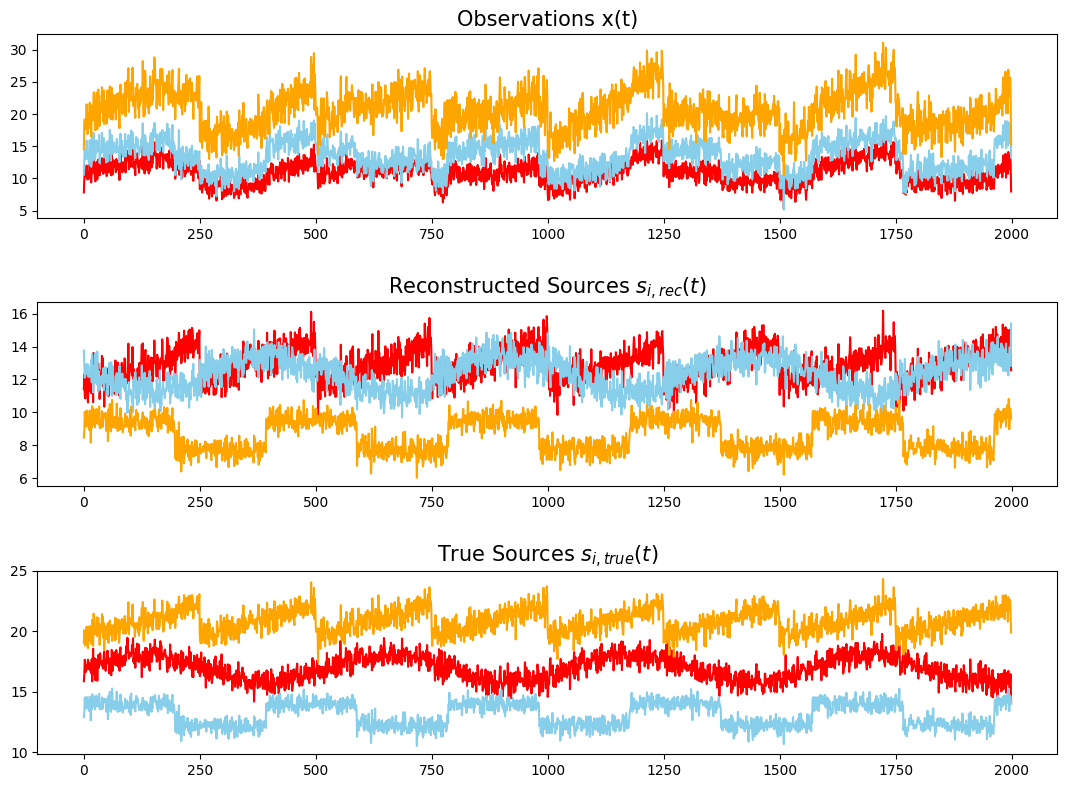

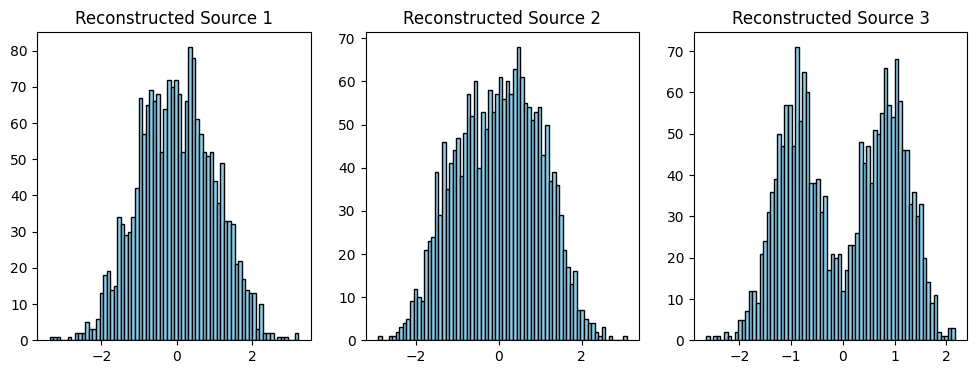

Answer 6:
Поскольку порядок восстановленных источников может меняться, то же самое происходит и с гистограммами. 
Поэтому аргументация должна быть более общей, и невозможно говорить о конкретном источнике, используя "Источник S1".
Один из восстановленных источников создает бимодальную гистограмму.  ----"два горба" на гистограмме -- типично для негауссовых сигналов (например, квадратная волна)
Два других источника дают распределение, которое (очень) приблизительно напоминает распределение Гаусса.
Однако обе эти гистограммы имеют более резкий пик (что означает более высокий эксцесс) и выглядят слегка искаженными.  --сигналы более "структурированы" чем случайный шум
Кроме того, хвосты выглядят тяжелее, чем при идеальном распределении по Гауссу.

Поскольку ICA ищет негауссовы распределения, эти распределения не вызывают особого удивления.
В частности, бимодальная гистограмма показывает, что восстановленный источник не имеет гауссова распределения.
Оба других реконструированных источника не

In [7]:
# S_true - чистые голоса певцов (только для проверки)         # X - то, что мы реально записали (смешанные голоса)
#  ICA -- из X восстановить S_true!

# Answer here

# 2. FastICA model
fast_ica = FastICA(n_components = 3)  # ICA на смешанных сигналах X (записях с микрофонов), чтобы разделить их на 3 независимых компонента.
S_reconstructed = fast_ica.fit_transform(X)
#print(S_reconstructed.shape)

# 3. Visualization of the data
visualize_data(models = [X, S_reconstructed, S_true], names = ["Observations x(t)", "Reconstructed Sources $s_{i,rec}(t)$", "True Sources $s_{i,true}(t)$"])
#    Верхний график: Записи с микрофонов (каша из голосов)
#Средний график: Разделенные голоса, которые нашла ICA
#Нижний график: Истинные голоса (для сравнения)

# 4. Comparing results
text_quest4 = """Answer 4:
Первое, на что следует обратить внимание, это то, что цвета не совпадают. 
Это имеет смысл, поскольку ICA не знает порядок расположения истинных источников, поэтому они каждый раз выбираются случайным образом.
В то время как некоторые реконструированные линии очень хорошо совпадают с истинными, другие реконструированные линии, похоже, перевернуты по знаку.
Кроме того, масштаб восстановленных линий не совсем соответствует действительности. 
Например, самый низкий из истинных источников находится в диапазоне от 10 до 15 по оси y, в то время как восстановленный источник не обязательно соответствует этому значению.
Это различие по оси y также приводит к тому, что расстояние между отдельными сигналами отличается от расстояния между истинными источниками.
Таким образом, порядок следования сигналов не обязательно совпадает, особенно по цвету.
Знак и масштабирование сигналов также могут отличаться от оригинальных источников.
Это разумно, поскольку ICA не знает истинного масштаба или знака сигналов, а математически различные масштабирования и перестановки все равно приводят к одному и тому же решению.
"""
print(text_quest4)

# 5. Histograms of estimated sources
#print(type(S_reconstructed))
reconstructed_s1 = S_reconstructed[:, 0]  #Строит распределения значений для каждого восстановленного голоса.
reconstructed_s2 = S_reconstructed[:, 1]
reconstructed_s3 = S_reconstructed[:, 2]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(S_reconstructed.shape[1]):
    axes[i].hist(S_reconstructed[:, i], bins=70, color='skyblue', edgecolor='k')
    axes[i].set_title(f"Reconstructed Source {i+1}")
plt.show()

# 6. Verifying the distributions
text_quest6 = """Answer 6:
Поскольку порядок восстановленных источников может меняться, то же самое происходит и с гистограммами. 
Поэтому аргументация должна быть более общей, и невозможно говорить о конкретном источнике, используя "Источник S1".
Один из восстановленных источников создает бимодальную гистограмму.  ----"два горба" на гистограмме -- типично для негауссовых сигналов (например, квадратная волна)
Два других источника дают распределение, которое (очень) приблизительно напоминает распределение Гаусса.
Однако обе эти гистограммы имеют более резкий пик (что означает более высокий эксцесс) и выглядят слегка искаженными.  --сигналы более "структурированы" чем случайный шум
Кроме того, хвосты выглядят тяжелее, чем при идеальном распределении по Гауссу.

Поскольку ICA ищет негауссовы распределения, эти распределения не вызывают особого удивления.
В частности, бимодальная гистограмма показывает, что восстановленный источник не имеет гауссова распределения.
Оба других реконструированных источника немного более гауссовы, но все же довольно сильно отклоняются от гауссова распределения (перекос,...).
"""
print(text_quest6)

## (Optional) Exercise 8: influence of data shuffling 
Now, we assume that the time information $t$ of the studio recording gets lost and verify the influence upon the ICA model.  
1. Generate a time-shuffled version of the observations $X_{shuffled}$. **Hint:** You can use the `np.random.permutation()` function to generate a permutation of timesteps $\{1, 2, ..., T\}$, which can be used to rearrange your dataset along one axis;
1. Compute an ICA model on the modified recordings $X_{shuffled}$ and un-shuffle the reconstructed independent sources $S_{rec,shuffled}$ such that it has the same temporal order as $S_{true}$. __Hint:__ You can use the `np.argsort()` function to invert the permutation you generated before;
1. Use the `visualize_data()` function to plot the reconstructed, unshuffled ICA-sources $S_{rec}$ and the true sources $S_{true}$;
1. Compare the reconstructed ICA-sources for the shuffled data and the non-shuffled data - can you give a reason for your observation?

**Note**: There are ICA variants that take temporal information into account to improve blind source separation of time series. See __[1](https://ieeexplore.ieee.org/document/554307/)__ and __[2](https://link.springer.com/chapter/10.1007/978-1-4471-1599-1_103)__ 

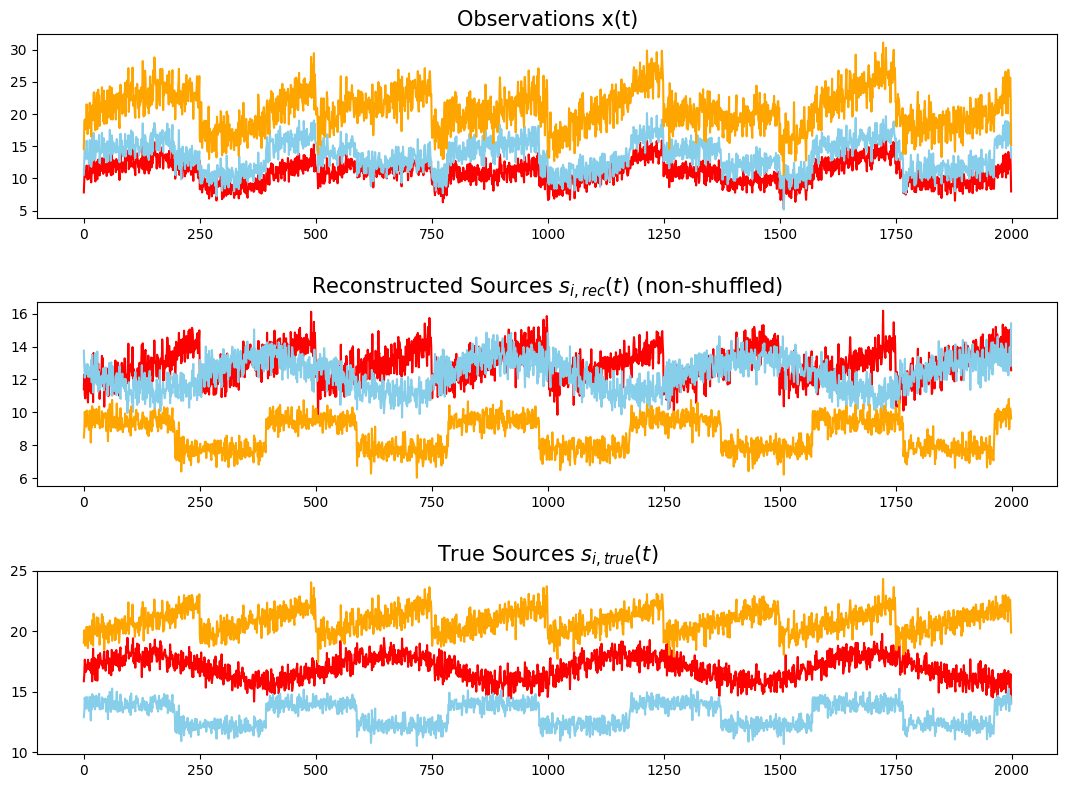

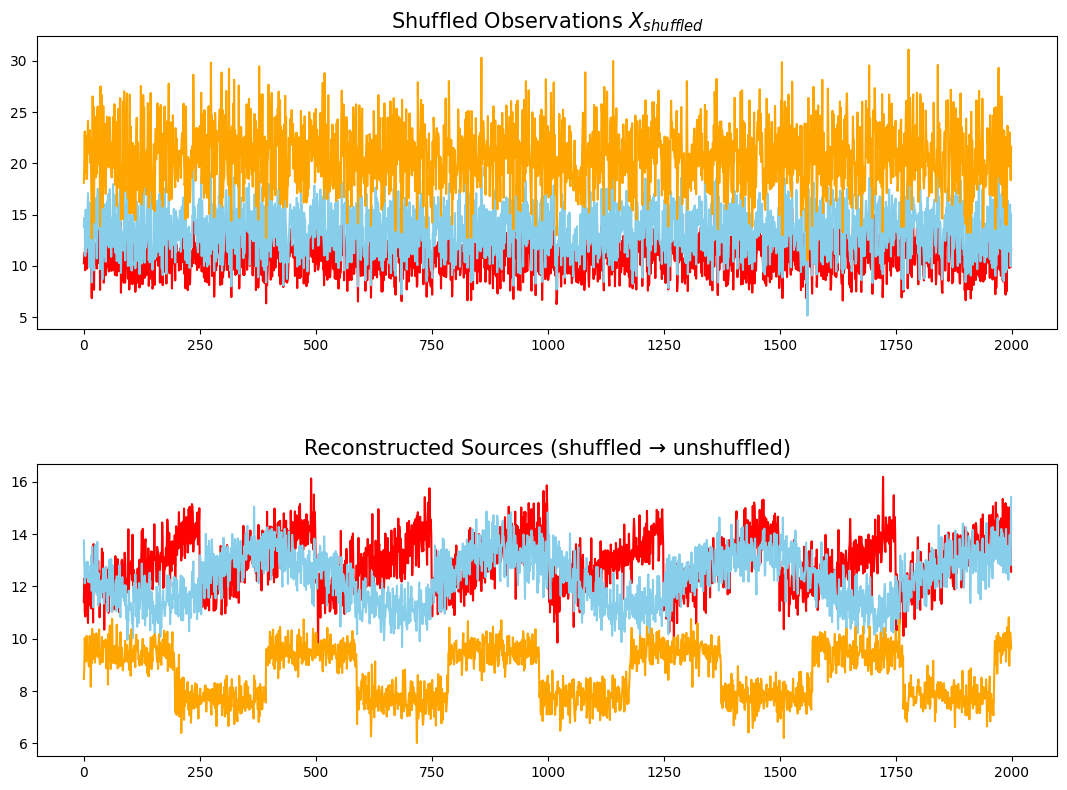

In [10]:
# 1. Take recordings from the X microphones and mixing them in time
perm = np.random.permutation(X.shape[0]) # random permutation of time indexes
X_shuffled = X[perm]   

# 2. FastICA model on X_shuffled
S_rec_shuffled = fast_ica.fit_transform(X_shuffled)

# Un-shuffle: Restoring the correct time order
indices_original = np.argsort(perm)  # to invert the permutation you generated before
S_rec_unshuffled = S_rec_shuffled[indices_original]


# 3. Visualization of the data
visualize_data(models = [X, S_reconstructed, S_true], names = ["Observations x(t)", "Reconstructed Sources $s_{i,rec}(t)$ (non-shuffled)", "True Sources $s_{i,true}(t)$"])
visualize_data(models = [X_shuffled, S_reconstructed], names = ["Shuffled Observations $X_{shuffled}$", "Reconstructed Sources (shuffled → unshuffled)"])


When mixing time series, observations lose their natural "shape" (for example, a sine wave turns into a chaotic signal). However, the ICA method works works based on STATISTICS (independence), not TIME (time sequence).
* ICA is looking for statistically independent signals
* If the signals are independent, their statistical properties are independent of the order.
* Therefore, in theory, ICA should work even with mixed data!  

After the "unshuffle" (return of time order), the restored sources look very similar to the usual ICA sources from exercsise 7. However, when viewing the mixed signals directly, they look like random noise.  

Conclusion: the time structure for the basic ICA is not important, the method works on distributions. However, in real-world tasks,  where time dependencies contain useful information, it is better to use time-sensitive ICA options.

## Exercise 9: remove ICA component from your observations
Now, we want to remove the contribution of two singers from the studio recordings $X$ such that only the contribution of singer 1 (sinusoidal waveform) remains. Therefore, you need to do the following steps:
1. Take the unmixing matrix $W=\hat A^{-1}$ of the component/s you want to keep and project the observation data $X$ to the  source space $S_{est}$;
2. Use the estimated mixing matrix $\hat A$ of the component/s you want to keep and project the reconstructed sources $S_{est}$ back to the observation space $X_{clean}$;
3. Visualize the cleaned observations $X_{clean}$, the original observations $X$ as well as the reconstructed sources $S_{est}$.

**Hint:** When selecting the components you want to remove from the observations, it might help to iteratively look at the cleaned observations $X_{clean}$ in order to see the effect.

**Hint:** When multiplying two vectors, think about your input and output dimensions. What kind of operation is required? Think about the inner product versus the outer product of two vectors.

**Note**: This procedure, removing ICA components from the data, is a useful one to remove (mixed) features (sources) from your data. In BCI, such "sources" could for instance be eye blinks, that have a clear spatial-temporal profile.

In [ ]:
# unmixing and mixing       Берем матрицы из обученной ICA модели
W = fast_ica.components_   # "Отвертка" - разбирает смесь на компоненты   (W = A^-1), переводит X -> S_reconstructed
A = fast_ica.mixing_       # "Инструкция сборки" - знает как компоненты смешались     переводит S_reconstructed -> X

# sources
S_est = S_reconstructed

# index of singer 1 in S_true
singer1_true_idx = 0       # В S_true певец 1 — это синусоида (первый сигнал)

# map singer 1 to reconstructed component           Определяем где какой певец---какой именно из трёх найденных ICA-компонентов соответствует певцу 1.
c = np.abs(np.corrcoef(S_est.T, S_true[:, singer1_true_idx], rowvar=True)[:S_est.shape[1], -1])
singer1_idx = int(np.argmax(c))
# Сравнивает восстановленные компоненты S_rec с истинными S_true :
# Считаем корреляцию каждого найденного источника с настоящей синусоидой.
# Берём тот, у кого корреляция максимальная → это наш певец 1

# keep only singer 1
S_keep = np.zeros_like(S_est)      # Создаём матрицу нулей (все источники убраны)
S_keep[:, singer1_idx] = S_est[:, singer1_idx]          # Возвращаем только источник певца 1

# cleaned observations
X_clean = S_keep @ A.T
# Теперь проецируем обратно в пространство микрофонов:
# берём оставшийся источник,
# через A.T получаем, как он звучал бы на каждом микрофоне.
# X_clean — это записи микрофонов, где остался только певец 1.

# visualize
visualize_data(
	models=[X, X_clean, S_est],
	names=["Observations x(t)", "Cleaned Observations $x_{clean}(t)$", "Reconstructed Sources $s_{i,rec}(t)$"]
)


## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Answer here